In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
# Separate genuine and fraud transactions

genuine = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

print("Genuine Transactions:", genuine.shape)
print("Fraud Transactions:", fraud.shape)

Genuine Transactions: (284315, 31)
Fraud Transactions: (492, 31)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

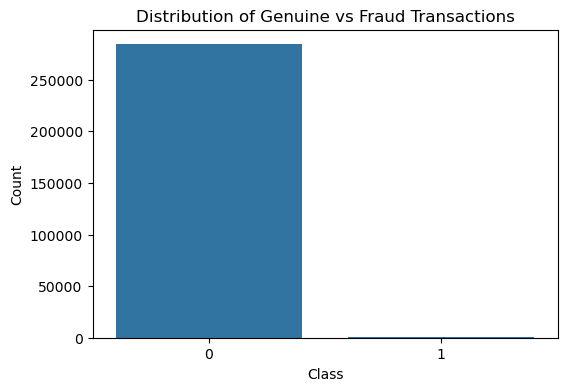

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Genuine vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

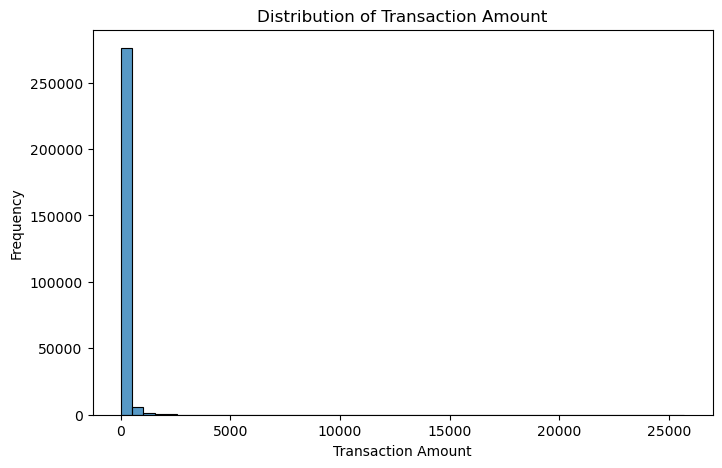

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amount")

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [11]:
# Compare average transaction amount

df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [12]:
# Features (Input)
X = df.drop("Class", axis=1)

# Target (Output)
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Data Shape: (227845, 30)
Testing Data Shape: (56962, 30)

Training Class Distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("✅ Logistic Regression Model Trained Successfully!")

✅ Logistic Regression Model Trained Successfully!


C:\Users\RASHIKA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# Predict on test data

y_pred = model.predict(X_test)

print(y_pred[:20])   # First 20 predictions

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9992977774656788


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.71      0.78        98

    accuracy                           1.00     56962
   macro avg       0.93      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962



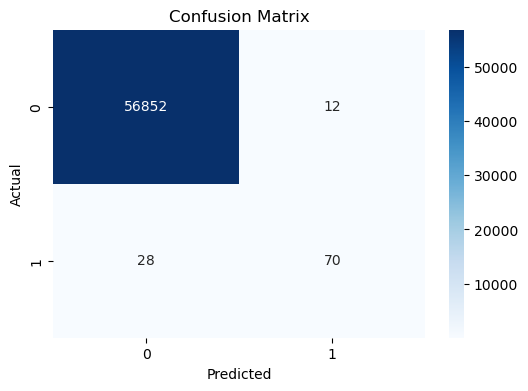

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully ✅")

Random Forest Trained Successfully ✅


In [20]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [21]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9995962220427653


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



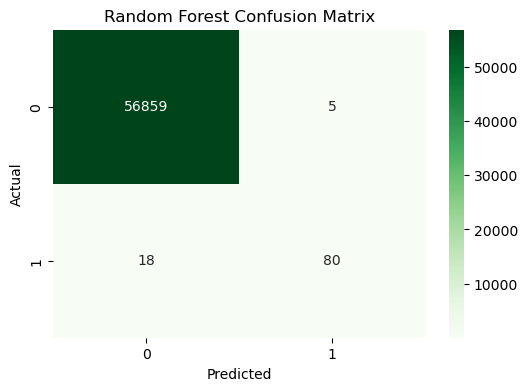

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
import joblib

joblib.dump(rf_model,"fraud_model.pkl")

['fraud_model.pkl']

In [25]:
joblib.load("fraud_model.pkl")

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
import os

print(os.getcwd())

C:\Users\RASHIKA


In [27]:
import os

print(os.listdir())

['.anaconda', '.android', '.antigravity', '.conda', '.continuum', '.copilot', '.emulator_console_auth_token', '.gemini', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'credit card.ipynb', 'creditcard.csv', 'credit_card_fraud.ipynb', 'Documents', 'Downloads', 'Ecommerce Customers', 'Favorites', 'fraud_model.pkl', 'IntelGraphicsProfiles', 'knn.ipynb', 'linearregression.ipynb', 'Links', 'Local Settings', 'ml-100k', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{c924435d-dd49-11f0-910a-548d5adc9f74}.TxR.0.regtrans-ms', 'NTUSER.DAT{c924435d-dd49-11f0-910a-548d5adc9f74}.TxR.1.regtrans-ms', 'NTUSER.DAT{c924435d-dd49-11f0-910a-548d5adc9f74}.TxR.2.regtrans-ms', 'NTUSER.DAT{c924435d-dd49-11f0-910a-548d5adc9f74}.TxR.blf', 'NTUSER.DAT{c924435e-dd49-11f0-910a-548